In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.preprocessing import LabelEncoder
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import re
import pickle

[nltk_data] Downloading package punkt to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Arup
[nltk_data]     sarkar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [97]:
import urllib.request

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
urllib.request.urlretrieve(url, "spam.tsv")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [98]:
df = pd.read_csv("spam.tsv",sep="\t",names=["label","message"])

In [99]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [100]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [101]:
df

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [102]:
def to_lower(dataframe,column_name):
    dataframe[column_name] = dataframe[column_name].str.lower()
    return dataframe

In [103]:
def remove_punctuations(dataframe,column_name):
    dataframe[column_name] = dataframe[column_name].apply(lambda x: re.sub(r'[^\w\s]','',x))
    return dataframe

In [104]:
def tokenize_message(dataframe,column_name):
    dataframe[column_name] = dataframe[column_name].apply(lambda x: word_tokenize(x))
    return dataframe

In [105]:
def remove_stopwords(dataframe,column_name):
    stop_words = set(stopwords.words('english'))
    dataframe[column_name] = dataframe[column_name].apply(lambda x: [word for word in x if word not in stop_words])
    return dataframe

In [106]:
def stemming(dataframe,column_name):
    porter = PorterStemmer()
    dataframe[column_name] = dataframe[column_name].apply(lambda x : [porter.stem(word) for word in x])
    return dataframe

In [107]:
df = to_lower(df,"message")
df = remove_punctuations(df,"message")
df = tokenize_message(df,"message")
df = remove_stopwords(df,"message")
df = stemming(df,"message")

In [108]:
df

,label,message
0,0,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,"[ok, lar, joke, wif, u, oni]"
2,1,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"[nah, dont, think, goe, usf, live, around, tho..."
...,...,...
5567,1,"[2nd, time, tri, 2, contact, u, u, 750, pound,..."
5568,0,"[ü, b, go, esplanad, fr, home]"
5569,0,"[piti, mood, soani, suggest]"
5570,0,"[guy, bitch, act, like, id, interest, buy, som..."


In [109]:
def list_to_string(dataframe,column_name):
    dataframe[column_name] = dataframe[column_name].apply(lambda x: " ".join(x))
    return dataframe

In [110]:
df = list_to_string(df,"message")

In [111]:
df

,label,message
0,0,go jurong point crazi avail bugi n great world...
1,0,ok lar joke wif u oni
2,1,free entri 2 wkli comp win fa cup final tkt 21...
3,0,u dun say earli hor u c alreadi say
4,0,nah dont think goe usf live around though
...,...,...
5567,1,2nd time tri 2 contact u u 750 pound prize 2 c...
5568,0,ü b go esplanad fr home
5569,0,piti mood soani suggest
5570,0,guy bitch act like id interest buy someth els ...


In [118]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['message'])

In [119]:
y = df['label']

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [123]:
model = MultinomialNB()
model.fit(X_train,y_train)
print("Model trained successfully!")

Model trained successfully!


In [124]:
y_pred = model.predict(X_test)

In [126]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9659192825112107


In [128]:
cm = confusion_matrix(y_test, y_pred)

In [129]:
cm

array([[965,   1],
       [ 37, 112]])

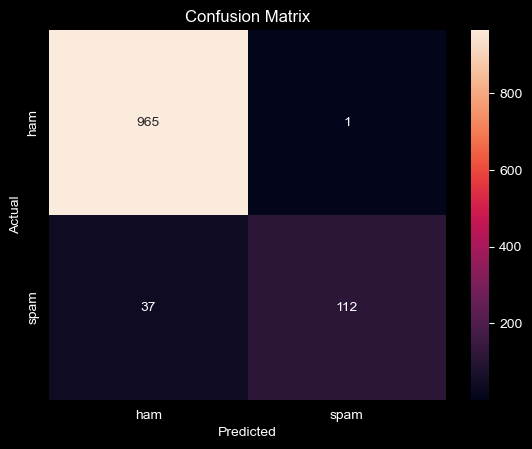

In [130]:
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["ham", "spam"],
            yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [133]:
model = {
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
}
for name,m in model.items():
    m.fit(X_train,y_train)
    y_pred = m.predict(X_test)
    print(f"Model trained successfully: {name}")
    print(f"Accuracy of {name}: {accuracy_score(y_test, y_pred)}")
    print(confusion_matrix(y_test, y_pred))
    print("-----------------------------------")

Model trained successfully: Random Forest
Accuracy of Random Forest: 0.9748878923766816
[[966   0]
 [ 28 121]]
-----------------------------------
Model trained successfully: Logistic Regression
Accuracy of Logistic Regression: 0.9560538116591928
[[965   1]
 [ 48 101]]
-----------------------------------


In [136]:
# Train standalone Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# Save both with pickle
with open("model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Saved successfully!")

Saved successfully!
